In [25]:
import cv2
import mediapipe
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
img = cv2.imread("pexels-cottonbro-8090149.jpg")

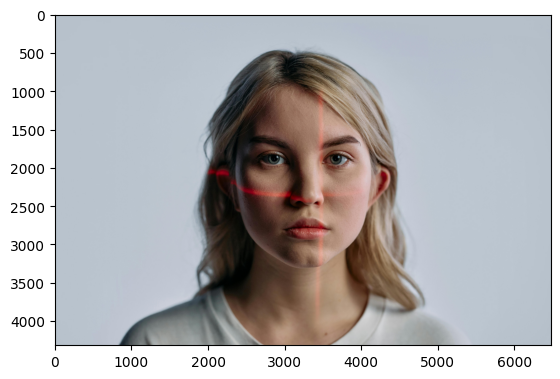

In [2]:
plt.imshow(img[:,:,::-1])

In [3]:
mp_face_mesh  = mediapipe.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode = True)


I0000 00:00:1772452992.227056       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [4]:
results = face_mesh.process(img[:,:,::-1])
results.multi_face_landmarks

[landmark {
   x: 0.50839514
   y: 0.62648433
   z: -0.03120908
 }
 landmark {
   x: 0.50796694
   y: 0.56567013
   z: -0.062065575
 }
 landmark {
   x: 0.5076076
   y: 0.58347756
   z: -0.0304844
 }
 landmark {
   x: 0.49635926
   y: 0.50390744
   z: -0.04873073
 }
 landmark {
   x: 0.5077096
   y: 0.5469621
   z: -0.0667854
 }
 landmark {
   x: 0.5071234
   y: 0.52192515
   z: -0.06285765
 }
 landmark {
   x: 0.50555557
   y: 0.4601987
   z: -0.033947453
 }
 landmark {
   x: 0.41481674
   y: 0.44744644
   z: 0.010891866
 }
 landmark {
   x: 0.5045246
   y: 0.41305894
   z: -0.028505445
 }
 landmark {
   x: 0.50425464
   y: 0.38740703
   z: -0.032916564
 }
 landmark {
   x: 0.5026567
   y: 0.2835678
   z: -0.024254367
 }
 landmark {
   x: 0.5085279
   y: 0.63558584
   z: -0.029511066
 }
 landmark {
   x: 0.5085682
   y: 0.6424074
   z: -0.025062228
 }
 landmark {
   x: 0.5085448
   y: 0.64519686
   z: -0.019509831
 }
 landmark {
   x: 0.508865
   y: 0.65112156
   z: -0.017112901
 }
 l

In [5]:
landmarks = results.multi_face_landmarks[0]

In [6]:
#lips =mp_face_mesh.FACEMESH_LIPS
face_oval =mp_face_mesh.FACEMESH_FACE_OVAL

In [8]:
face_oval

frozenset({(10, 338),
           (21, 54),
           (54, 103),
           (58, 132),
           (67, 109),
           (93, 234),
           (103, 67),
           (109, 10),
           (127, 162),
           (132, 93),
           (136, 172),
           (148, 176),
           (149, 150),
           (150, 136),
           (152, 148),
           (162, 21),
           (172, 58),
           (176, 149),
           (234, 127),
           (251, 389),
           (284, 251),
           (288, 397),
           (297, 332),
           (323, 361),
           (332, 284),
           (338, 297),
           (356, 454),
           (361, 288),
           (365, 379),
           (377, 152),
           (378, 400),
           (379, 378),
           (389, 356),
           (397, 365),
           (400, 377),
           (454, 323)})

In [9]:
df = pd.DataFrame(list(face_oval), columns=["p1", "p2"])

In [10]:
df.head()

,p1,p2
0,176,149
1,297,332
2,150,136
3,109,10
4,356,454


In [11]:
df.shape

(36, 2)

In [21]:
routes_idx = []
p1= df.iloc[0]["p1"]
p2 = df.iloc[0]["p2"]
for i in range(0, df.shape[0]):
    obj = df[df["p1"]==p2]
    p1=obj["p1"].values[0]
    p2=obj["p2"].values[0]

    current_route = []
    current_route.append(p1)
    current_route.append(p2)
    routes_idx.append(current_route)

In [22]:
for route_idx in routes_idx:
    print(f"Draw a line from {route_idx[0]} landmark point to {route_idx[1]} landmark point")

Draw a line from 149 landmark point to 150 landmark point
Draw a line from 150 landmark point to 136 landmark point
Draw a line from 136 landmark point to 172 landmark point
Draw a line from 172 landmark point to 58 landmark point
Draw a line from 58 landmark point to 132 landmark point
Draw a line from 132 landmark point to 93 landmark point
Draw a line from 93 landmark point to 234 landmark point
Draw a line from 234 landmark point to 127 landmark point
Draw a line from 127 landmark point to 162 landmark point
Draw a line from 162 landmark point to 21 landmark point
Draw a line from 21 landmark point to 54 landmark point
Draw a line from 54 landmark point to 103 landmark point
Draw a line from 103 landmark point to 67 landmark point
Draw a line from 67 landmark point to 109 landmark point
Draw a line from 109 landmark point to 10 landmark point
Draw a line from 10 landmark point to 338 landmark point
Draw a line from 338 landmark point to 297 landmark point
Draw a line from 297 landm

In [ ]:
routes = []

for source_idx, target_idx in routes_idx:
    source = landmarks.landmark[source_idx]
    target = landmarks.landmark[target_idx]

    relative_source = (int(source.x * img.shape[1]), int(source.y * img.shape[0]))
    relative_target = (int(target.x * img.shape[1]), int(target.y * img.shape[0]))

    routes.append(relative_source)
    routes.append(relative_target)
    


In [24]:
routes[0:5]

[(2917, 3152), (2813, 3086), (2813, 3086), (2688, 2986), (2688, 2986)]

In [26]:
mask = np.zeros((img.shape[0], img.shape[1]))
mask = cv2.fillConvexPoly(mask, np.array(routes),1)
mask= mask.astype(bool)

out = np.zeros_like(img)
out[mask] = img[mask]
 


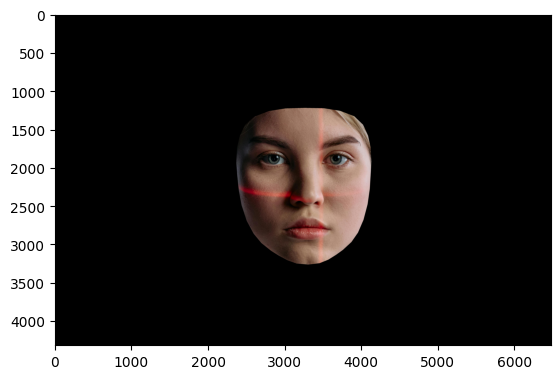

In [28]:
plt.imshow(out[:,:,::-1])

In [1]:
import cv2
import mediapipe as mp
import numpy as np

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

image = cv2.imread("face.jpg")
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

results = face_mesh.process(rgb)

h, w, _ = image.shape

# Lip landmark indexes
LIP_INDEXES = [61,146,91,181,84,17,314,405,321,375,
               291,308,324,318,402,317,14,87,178,88,95]

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        lip_points = []
        for idx in LIP_INDEXES:
            x = int(face_landmarks.landmark[idx].x * w)
            y = int(face_landmarks.landmark[idx].y * h)
            lip_points.append((x, y))
            cv2.circle(image, (x,y), 2, (0,255,0), -1)

cv2.imshow("Lips", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

I0000 00:00:1772511758.938980       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
[ WARN:0@3.173] global loadsave.cpp:278 findDecoder imread_('face.jpg'): can't open/read file: check file path/integrity
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,  # better lip precision
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Lip landmark indexes (outer + inner)
LIP_INDEXES = [
    61,146,91,181,84,17,314,405,321,375,
    291,308,324,318,402,317,14,87,178,88,95,
    78,95,88,178,87,14,317,402,318,324,
    308,415,310,311,312,13,82,81,80,191
]

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb_frame)

    h, w, _ = frame.shape

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            lip_points = []

            # Collect lip points
            for idx in LIP_INDEXES:
                x = int(face_landmarks.landmark[idx].x * w)
                y = int(face_landmarks.landmark[idx].y * h)
                lip_points.append((x, y))

                # Draw small circle on lip landmarks
                cv2.circle(frame, (x, y), 1, (0, 255, 0), -1)

            # Convert to numpy array
            lip_array = np.array(lip_points)

            # Bounding box around lips
            x_min, y_min = np.min(lip_array, axis=0)
            x_max, y_max = np.max(lip_array, axis=0)

            # Add padding
            padding = 10
            x_min = max(0, x_min - padding)
            y_min = max(0, y_min - padding)
            x_max = min(w, x_max + padding)
            y_max = min(h, y_max + padding)

            # Draw bounding box
            cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)

            # Crop lip ROI
            lip_roi = frame[y_min:y_max, x_min:x_max]

            # Resize for model input (optional)
            if lip_roi.size != 0:
                lip_roi_resized = cv2.resize(lip_roi, (112, 112))
                cv2.imshow("Lip ROI", lip_roi_resized)

    cv2.imshow("Lip Detection - MediaPipe Only", frame)

    if cv2.waitKey(1) & 0xFF == 27:  # Press ESC to exit
        break

cap.release()
cv2.destroyAllWindows()

I0000 00:00:1772512488.104959       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


KeyboardInterrupt: 

: 

# just lips 

In [ ]:
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Lip landmark indexes (outer + inner)
LIP_INDEXES = [
    61,146,91,181,84,17,314,405,321,375,
    291,308,324,318,402,317,14,87,178,88,95,
    78,95,88,178,87,14,317,402,318,324,
    308,415,310,311,312,13,82,81,80,191
]

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    h, w, _ = frame.shape

    # Create black mask
    lip_mask = np.zeros((h, w), dtype=np.uint8)

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            lip_points = []

            for idx in LIP_INDEXES:
                x = int(face_landmarks.landmark[idx].x * w)
                y = int(face_landmarks.landmark[idx].y * h)
                lip_points.append([x, y])

            lip_points = np.array(lip_points, dtype=np.int32)

            # Fill lip polygon on mask
            cv2.fillPoly(lip_mask, [lip_points], 255)

    # Apply mask to original frame
    lip_only = cv2.bitwise_and(frame, frame, mask=lip_mask)

    cv2.imshow("Only Lips", lip_only)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

I0000 00:00:1772512042.066012       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


KeyboardInterrupt: 

: 

# squre around lips and lips detection

In [ ]:
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Lip landmarks
LIP_INDEXES = [
    61,146,91,181,84,17,314,405,321,375,
    291,308,324,318,402,317,14,87,178,88,95,
    78,95,88,178,87,14,317,402,318,324,
    308,415,310,311,312,13,82,81,80,191
]

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    h, w, _ = frame.shape

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            lip_points = []

            for idx in LIP_INDEXES:
                x = int(face_landmarks.landmark[idx].x * w)
                y = int(face_landmarks.landmark[idx].y * h)
                lip_points.append([x, y])

            lip_points = np.array(lip_points, dtype=np.int32)

            # Create mask for full frame
            full_mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(full_mask, [lip_points], 255)

            # Get bounding box
            x_min, y_min = np.min(lip_points, axis=0)
            x_max, y_max = np.max(lip_points, axis=0)

            # Convert to square box
            box_width = x_max - x_min
            box_height = y_max - y_min
            box_size = max(box_width, box_height)

            center_x = (x_min + x_max) // 2
            center_y = (y_min + y_max) // 2

            half_size = box_size // 2 + 15  # padding

            x1 = max(center_x - half_size, 0)
            y1 = max(center_y - half_size, 0)
            x2 = min(center_x + half_size, w)
            y2 = min(center_y + half_size, h)

            # Draw square box on original frame
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Crop square region
            square_crop = frame[y1:y2, x1:x2]
            square_mask = full_mask[y1:y2, x1:x2]

            # Apply mask inside square
            lip_square_only = cv2.bitwise_and(square_crop, square_crop, mask=square_mask)

            if lip_square_only.size != 0:
                lip_square_only = cv2.resize(lip_square_only, (112, 112))
                cv2.imshow("Square Lip Region", lip_square_only)

    cv2.imshow("Frame with Square Box", frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

I0000 00:00:1772512432.281471       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


KeyboardInterrupt: 

: 

# only lip in rectangular box 

In [ ]:
import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Lip landmark indexes
LIP_INDEXES = [
    61,146,91,181,84,17,314,405,321,375,
    291,308,324,318,402,317,14,87,178,88,95,
    78,95,88,178,87,14,317,402,318,324,
    308,415,310,311,312,13,82,81,80,191
]

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)

    h, w, _ = frame.shape

    # Black output image
    output = np.zeros_like(frame)

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            lip_points = []

            for idx in LIP_INDEXES:
                x = int(face_landmarks.landmark[idx].x * w)
                y = int(face_landmarks.landmark[idx].y * h)
                lip_points.append([x, y])

            lip_points = np.array(lip_points)

            # Bounding box
            x_min, y_min = np.min(lip_points, axis=0)
            x_max, y_max = np.max(lip_points, axis=0)

            padding = 15
            x_min = max(0, x_min - padding)
            y_min = max(0, y_min - padding)
            x_max = min(w, x_max + padding)
            y_max = min(h, y_max + padding)

            # Copy rectangular region from original frame
            output[y_min:y_max, x_min:x_max] = frame[y_min:y_max, x_min:x_max]

    cv2.imshow("Rectangular Lip Region Only", output)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

I0000 00:00:1772512840.495058       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


KeyboardInterrupt: 

: 